**Convolutional Neural Network for MNIST Digit Classification**

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Load the MNIST dataset.
# MNIST contains 60,000 training images and 10,000 test images
# The data consists of 28x28 pixel grayscale images of handwritten digits (0-9).
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [10]:
# Preprocess the data
# CNNs expect input data to have shape (height, width, channels)
# MNIST images are grayscale, so channels = 1
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [11]:
# For multi-class classification, our integer labels (0-9) must be converted
# to a "one-hot encoded" format. For example, the digit '5' becomes [0, 0, 0, 0, 0, 1, 0, 0, 0, 0].
num_classes = 10
y_train_one_hot = to_categorical(y_train, num_classes)
y_test_one_hot = to_categorical(y_test, num_classes)

In [12]:
# Build the CNN model
# A CNN uses a series of layers to progressively learn more complex features.
# 1. Convolutional Layer: Finds patterns like edges and shapes.
# 2. Pooling Layer: Reduces the size of the image, helping to generalize features.
# 3. Flatten Layer: Converts the 2D data to a 1D vector.
# 4. Dense Layers: Classifies the flattened features.


model = Sequential([
# First set of Conv2D and MaxPooling2D layers.
# We use 32 filters (small feature detectors) with a 3x3 kernel size.
Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
MaxPooling2D((2,2)),

# Second set of Conv2D and MaxPooling2D layers.
# This learns more abstract features from the outputs of the first layers.
Conv2D(64, (3,3), activation='relu'),
MaxPooling2D((2,2)),

# Flatten the 2D feature maps to a 1D vector to feed into the dense layers.
Flatten(),

# A standard dense layer to process the features before the final output.
Dense(64, activation='relu'),

# The output layer. It has 10 neurons, one for each digit (0-9).
# 'softmax' activation gives a probability for each class.
Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the model
# Loss function: sparse_categorical_crossentropy (since labels are integers 0–9)
# Optimizer: Adam (efficient optimization algorithm)
# Metric: accuracy (to measure performance)
model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

In [17]:
# The training process involves feeding the data to the model and letting it learn.
# 'epochs=5': The model will go through the entire dataset 5 times.
# 'batch_size=64': The model will process 64 images at a time.
# 'validation_split=0.1': We hold out 10% of the training data to monitor for overfitting.
history = model.fit(x_train, y_train_one_hot,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.9945 - loss: 0.0173 - val_accuracy: 0.9898 - val_loss: 0.0339
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.9955 - loss: 0.0147 - val_accuracy: 0.9902 - val_loss: 0.0374
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.9970 - loss: 0.0098 - val_accuracy: 0.9877 - val_loss: 0.0489
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.9972 - loss: 0.0085 - val_accuracy: 0.9892 - val_loss: 0.0462
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.9976 - loss: 0.0070 - val_accuracy: 0.9903 - val_loss: 0.0409


In [18]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test_one_hot, verbose=2)
print("\nTest Accuracy:", test_acc)
print("\nTest Loss:", test_loss)

313/313 - 2s - 8ms/step - accuracy: 0.9905 - loss: 0.0348

Test Accuracy: 0.9904999732971191

Test Loss: 0.03481593728065491


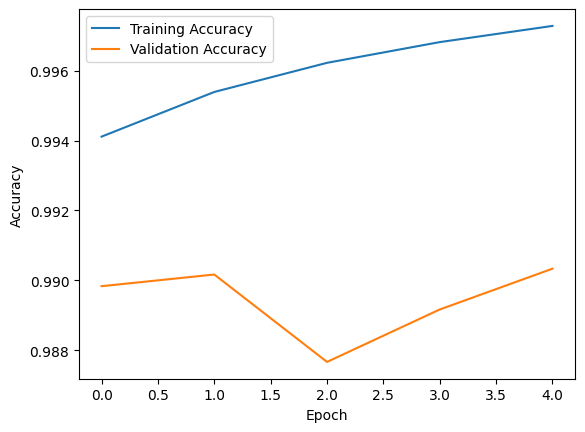

In [19]:
# Plot Training Results (Accuracy & Loss)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
True Label: 9
Predicted Label: 9


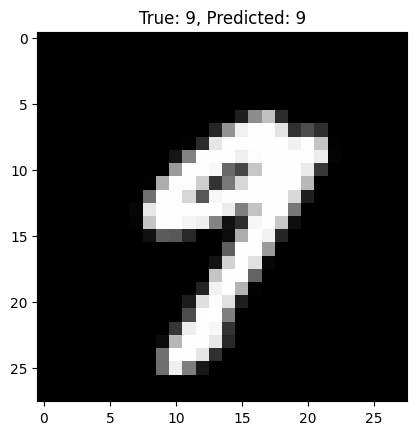

In [21]:
# Predict a single image from the test set
index = 20 # You can change index to see other images
sample_image = x_test[index]
sample_label = y_test[index]

# Model expects batch dimension, so reshape
sample_image_expanded = np.expand_dims(sample_image, axis=0)

# Make prediction
prediction = model.predict(sample_image_expanded)
predicted_class = np.argmax(prediction)

print("True Label:", sample_label)
print("Predicted Label:", predicted_class)

# Show the image
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"True: {sample_label}, Predicted: {predicted_class}")
plt.show()